# Mushroom Classification: Logistic Regression in PyTorch

A logistic-regression classifier for the mushroom dataset implemented in PyTorch — a single linear layer with a sigmoid output, trained with binary cross-entropy loss.

In [1]:
# @title
# Download a processed version of the data
!wget  https://huggingface.co/hk/hw1/resolve/main/mushroom.txt

--2025-11-17 06:56:17--  https://huggingface.co/hk/hw1/resolve/main/mushroom.txt
Resolving huggingface.co (huggingface.co)... 3.170.185.25, 3.170.185.35, 3.170.185.14, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.25|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/models/hk/hw1/d23e2ca56c2eb67af93a318c77348b936dcf4d12/mushroom.txt?%2Fhk%2Fhw1%2Fresolve%2Fmain%2Fmushroom.txt=&etag=%2212401d069edc9c3b8be14236a657b917ab324a19%22 [following]
--2025-11-17 06:56:18--  https://huggingface.co/api/resolve-cache/models/hk/hw1/d23e2ca56c2eb67af93a318c77348b936dcf4d12/mushroom.txt?%2Fhk%2Fhw1%2Fresolve%2Fmain%2Fmushroom.txt=&etag=%2212401d069edc9c3b8be14236a657b917ab324a19%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response... 200 OK
Length: 1264848 (1.2M) [text/plain]
Saving to: ‘mushroom.txt’

mushroom.txt        100%[===================>]   1.21M  --.-KB/s    in 0.06s   

2025-11-

In [2]:
# Use only the provided packages!
import csv
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [3]:
# load data from txt
# X.shape = (n_examples, n_features), y.shape = (n_examples, )
def load_data(filename):
    data = pandas.read_csv(filename).to_numpy()
    n = data.shape[0]
    d = data.shape[1] - 1

    # Map strings to numbers
    X = np.zeros((n, d))
    for i in range(d):
        mapping = {name: j for j, name in enumerate(sorted(set(data[:, i+1])))}
        for j in range(n):
            X[j, i] = mapping[data[j, i+1]]
    mapping = {'EDIBLE': 1, 'POISONOUS': 0}
    y = np.zeros(n, dtype=np.int32)
    for j in range(n):
        y[j] = mapping[data[j, 0]]

    # We only use these 6 features
    features = [0, 2, 8, 10, 15, 17]
    X = np.take(X, features, axis=-1)

    return X, y

In [4]:
def create_data(filename, test_size=0.15, val_size=0.15):
    # Load the dataset
    X, y = load_data(filename='mushroom.txt')

    # Split into train, validation, test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size, random_state=42)
    X_train, X_val, X_test = torch.Tensor(X_train), torch.Tensor(X_val), torch.Tensor(X_test)
    y_train = torch.Tensor(np.array([ [y] for y in y_train ]))
    y_val = torch.Tensor(np.array([ [y] for y in y_val ]))
    y_test = torch.Tensor(np.array([ [y] for y in y_test ]))

    return X_train, y_train, X_val, y_val, X_test, y_test

In [5]:
def get_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, train_batch_size=16, test_batch_size=32):
    # part a: Create dataloaders for train, validation and test sets
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size= train_batch_size, shuffle= True)
    val_loader = DataLoader(val_dataset, batch_size= test_batch_size)
    test_loader = DataLoader(test_dataset, batch_size= test_batch_size)

    return train_loader, val_loader, test_loader

In [6]:
def evaluate_loss(model, criterion, dataloader):
    model.eval()
    total_loss = 0.0
    for batch_X, batch_y in dataloader:
        batch_size = len(batch_X)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        total_loss += loss.item()

    return total_loss / len(dataloader.dataset)

In [7]:
def evaluate_acc(model, dataloader):
    model.eval()
    total_acc = 0.0
    for batch_X, batch_y in dataloader:
        outputs = model(batch_X)
        predictions = (outputs > 0.5).long()
        total_acc += (predictions==batch_y).sum()

    return total_acc / len(dataloader.dataset)

In [8]:
######################################################################
# OneLayerNetwork -- ALSO A LOGISTIC REGRESSION MODEL
######################################################################

class OneLayerNetwork(torch.nn.Module):
    def __init__(self, input_features):
        # input_features: int
        super(OneLayerNetwork, self).__init__()

        ### part c: implement OneLayerNetwork with torch.nn.Linear. Use sigmoid as the activation
        self.linear = torch.nn.Linear(input_features, 1)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # x.shape = (n_batch, n_features)

        ### part c: implement the foward function
        outputs = self.sigmoid(self.linear(x))
        return outputs

In [9]:
def init_oneLayerNN(in_features, lr):
    # input_features: int -> Number of input features
    # lr: float -> Learning Rate

    ### part d: prepare the OneLayerNetwork model, criterion, and optimizer
    model = OneLayerNetwork(in_features)
    criterion = torch.nn.BCELoss(reduction= 'sum')
    optimizer = torch.optim.SGD(model.parameters(), lr = lr)
    return model, criterion, optimizer

In [10]:
######################################################################
# TwoLayerNetwork
######################################################################

class TwoLayerNetwork(torch.nn.Module):
    def __init__(self, input_features, hidden_features, first_activation='sigmoid'):
        # input_features: int -> Number of input features
        # hidden_features: int -> Size of the hidden layer
        # first_activation: str -> Activation to use for the first hidden layer

        super(TwoLayerNetwork, self).__init__()
        ### part e: implement TwoLayerNetwork with torch.nn.Linear. Use sigmoid as the activation for both layers
        self.linear_ = torch.nn.Linear(input_features, hidden_features)
        self.linear_h = torch.nn.Linear(hidden_features, 1)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # x.shape = (n_batch, n_features)

        ### part e: implement the foward function
        hidden = self.sigmoid(self.linear_(x))
        outputs = self.sigmoid(self.linear_h(hidden))
        return outputs

In [11]:
def init_twoLayerNN(in_features, hidden_size, first_activation, lr):
    # input_features: int -> Number of input features
    # hidden_features: int -> Size of the hidden layer
    # first_activation: str -> Activation to use for the first hidden layer
    # lr: float -> Learning Rate

    ### part f: prepare the TwoLayerNetwork model, criterion, and optimizer
    model = TwoLayerNetwork(in_features, hidden_size, first_activation)
    criterion = torch.nn.BCELoss(reduction= 'sum')
    optimizer = torch.optim.SGD(model.parameters(), lr = lr)

    return model, criterion, optimizer

In [12]:
def train(model, criterion, optimizer, train_loader, valid_loader, num_epochs, logging_epochs=1):
    print("Start training model...")

    train_loss_list = []
    valid_loss_list = []
    train_acc_list = []
    valid_acc_list = []
    for epoch in range(1, num_epochs+1):
        model.train()
        for batch_X, batch_y in train_loader:
            ### part g: Build the training paradigm - Zero out gradients, forward pass, compute loss, loss backward, update model
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        train_loss = evaluate_loss(model, criterion, train_loader)
        valid_loss = evaluate_loss(model, criterion, valid_loader)
        train_acc = evaluate_acc(model, train_loader)
        valid_acc = evaluate_acc(model, valid_loader)
        train_loss_list.append(train_loss)
        valid_loss_list.append(valid_loss)
        train_acc_list.append(train_acc)
        valid_acc_list.append(valid_acc)

        if logging_epochs > 0 and epoch % logging_epochs == 0:
            print(f"| epoch {epoch:2d} | train loss {train_loss:.6f} | train acc {train_acc:.6f} | valid loss {valid_loss:.6f} | valid acc {valid_acc:.6f} |")

    return train_loss_list, valid_loss_list, train_acc_list, valid_acc_list

In [13]:
# fix random seed
np.random.seed(42)
torch.manual_seed(42)

In [14]:
# Data Preparation
train_batch_size = 16
test_batch_size = 32

## Load data
X_train, y_train, X_val, y_val, X_test, y_test = create_data("mushroom.txt")

## Create data loaders
train_loader, val_loader, test_loader = get_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, train_batch_size=train_batch_size, test_batch_size=test_batch_size)

In [15]:
## Define hyperparameters
lr = 0.001
num_epochs = 50

## Init models
oneLayerNN, criterion, optimizer = init_oneLayerNN(X_train.shape[1], lr=lr)
results_one = train(oneLayerNN, criterion, optimizer, train_loader, val_loader, num_epochs=num_epochs)

Start training model...
| epoch  1 | train loss 0.557378 | train acc 0.715414 | valid loss 0.559479 | valid acc 0.715750 |
| epoch  2 | train loss 0.546404 | train acc 0.727093 | valid loss 0.543314 | valid acc 0.736253 |
| epoch  3 | train loss 0.534622 | train acc 0.735976 | valid loss 0.534198 | valid acc 0.749301 |
| epoch  4 | train loss 0.536712 | train acc 0.739102 | valid loss 0.542148 | valid acc 0.743709 |
| epoch  5 | train loss 0.528689 | train acc 0.733838 | valid loss 0.534176 | valid acc 0.735322 |
| epoch  6 | train loss 0.528647 | train acc 0.768218 | valid loss 0.535205 | valid acc 0.770736 |
| epoch  7 | train loss 0.524880 | train acc 0.758184 | valid loss 0.531868 | valid acc 0.759553 |
| epoch  8 | train loss 0.530940 | train acc 0.742556 | valid loss 0.535152 | valid acc 0.751165 |
| epoch  9 | train loss 0.521009 | train acc 0.757526 | valid loss 0.528466 | valid acc 0.762349 |
| epoch 10 | train loss 0.523456 | train acc 0.752097 | valid loss 0.530420 | valid a

In [16]:
## Define hyperparameters
lr = 0.001
hidden_size = 6
activation = 'sigmoid'
num_epochs = 50

## Init models
twoLayerNN, criterion, optimizer = init_twoLayerNN(X_train.shape[1], hidden_size, activation, lr=lr)
results_two = train(twoLayerNN, criterion, optimizer, train_loader, val_loader, num_epochs=num_epochs)

Start training model...
| epoch  1 | train loss 0.678097 | train acc 0.525909 | valid loss 0.674994 | valid acc 0.557316 |
| epoch  2 | train loss 0.663843 | train acc 0.610956 | valid loss 0.662280 | valid acc 0.623486 |
| epoch  3 | train loss 0.647194 | train acc 0.620003 | valid loss 0.643383 | valid acc 0.630941 |
| epoch  4 | train loss 0.626839 | train acc 0.685475 | valid loss 0.621754 | valid acc 0.691519 |
| epoch  5 | train loss 0.601474 | train acc 0.714591 | valid loss 0.596573 | valid acc 0.719478 |
| epoch  6 | train loss 0.574962 | train acc 0.754565 | valid loss 0.570228 | valid acc 0.767008 |
| epoch  7 | train loss 0.551367 | train acc 0.743708 | valid loss 0.548664 | valid acc 0.753961 |
| epoch  8 | train loss 0.533270 | train acc 0.751275 | valid loss 0.531942 | valid acc 0.757689 |
| epoch  9 | train loss 0.520149 | train acc 0.755058 | valid loss 0.520067 | valid acc 0.759553 |
| epoch 10 | train loss 0.509807 | train acc 0.763119 | valid loss 0.510060 | valid a

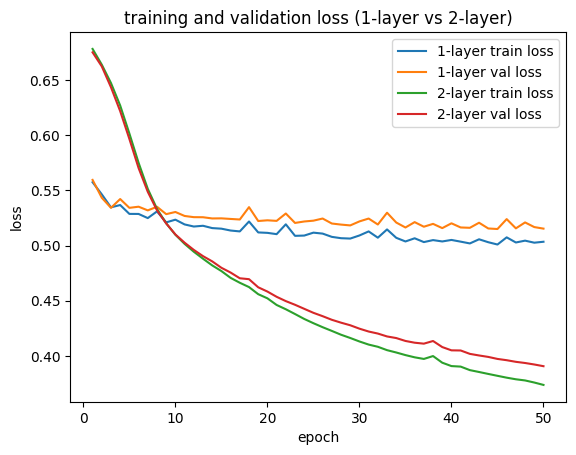

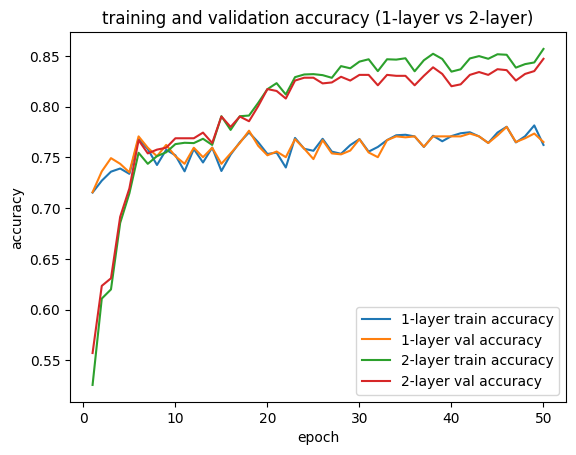

In [17]:
one_train_loss, one_valid_loss, one_train_acc, one_valid_acc = results_one
two_train_loss, two_valid_loss, two_train_acc, two_valid_acc = results_two

### part h: Plot the loss for training/validation for both the models on the same curve
epochs =range(1,num_epochs+1)
plt.plot(epochs, one_train_loss, label='1-layer train loss')
plt.plot(epochs, one_valid_loss, label='1-layer val loss')
plt.plot(epochs, two_train_loss, label='2-layer train loss')
plt.plot(epochs, two_valid_loss, label='2-layer val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training and validation loss (1-layer vs 2-layer)')
plt.legend()
plt.show()

### part h: Plot the accuracies for training/validation for both the models on the same curve
plt.plot(epochs, one_train_acc, label='1-layer train accuracy')
plt.plot(epochs, one_valid_acc, label='1-layer val accuracy')
plt.plot(epochs, two_train_acc, label='2-layer train accuracy')
plt.plot(epochs, two_valid_acc, label='2-layer val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('training and validation accuracy (1-layer vs 2-layer)')
plt.legend()
plt.show()

In [18]:
### part i: Evaluate the test accuracies for both the models. Explain the behavior
one_test_acc = evaluate_acc(oneLayerNN, test_loader)
two_test_acc = evaluate_acc(twoLayerNN, test_loader)

print("1-layer NN test accuracy:", one_test_acc)
print("2-layer NN test accuracy:", two_test_acc)

1-layer NN test accuracy: tensor(0.7664)
2-layer NN test accuracy: tensor(0.8416)


In [19]:
def get_confusion_matrix(model, dataloader):
    ### part j: Create confusion matrix for the given data loader
    y_pred = []
    y_true = []

    model.eval()
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            outputs = model(batch_X)
            pred = (outputs >= 0.5).long()
            y_pred.append(pred)
            y_true.append(batch_y)

    # concatenate batches into single vectors
    y_pred = torch.cat(y_pred).numpy().flatten()
    y_true = torch.cat(y_true).numpy().flatten()

    cm = confusion_matrix(y_true, y_pred)

    return cm

In [20]:
oneLayerNN_cm = get_confusion_matrix(oneLayerNN, val_loader)
twoLayerNN_cm = get_confusion_matrix(twoLayerNN, val_loader)

print ("Confusion Matrix for One Layer NN")
print (oneLayerNN_cm)

print ("Confusion Matrix for Two Layer NN")
print (twoLayerNN_cm)

Confusion Matrix for One Layer NN
[[402 120]
 [132 419]]
Confusion Matrix for Two Layer NN
[[405 117]
 [ 47 504]]


tuned hyperparameters:
lr: 0.005
num_epochs: 100
hidden_size:  12
activation: sigmoid
Start training model...
| epoch  1 | train loss 0.581762 | train acc 0.754236 | valid loss 0.580929 | valid acc 0.751165 |
| epoch  2 | train loss 0.505650 | train acc 0.776114 | valid loss 0.509518 | valid acc 0.774464 |
| epoch  3 | train loss 0.470789 | train acc 0.779240 | valid loss 0.479032 | valid acc 0.777260 |
| epoch  4 | train loss 0.436288 | train acc 0.822504 | valid loss 0.448056 | valid acc 0.817335 |
| epoch  5 | train loss 0.428677 | train acc 0.839612 | valid loss 0.444302 | valid acc 0.827586 |
| epoch  6 | train loss 0.411183 | train acc 0.856062 | valid loss 0.428904 | valid acc 0.843430 |
| epoch  7 | train loss 0.394368 | train acc 0.848166 | valid loss 0.413364 | valid acc 0.828518 |
| epoch  8 | train loss 0.382718 | train acc 0.846192 | valid loss 0.402906 | valid acc 0.834110 |
| epoch  9 | train loss 0.373698 | train acc 0.852278 | valid loss 0.395496 | valid acc 0.842498 |

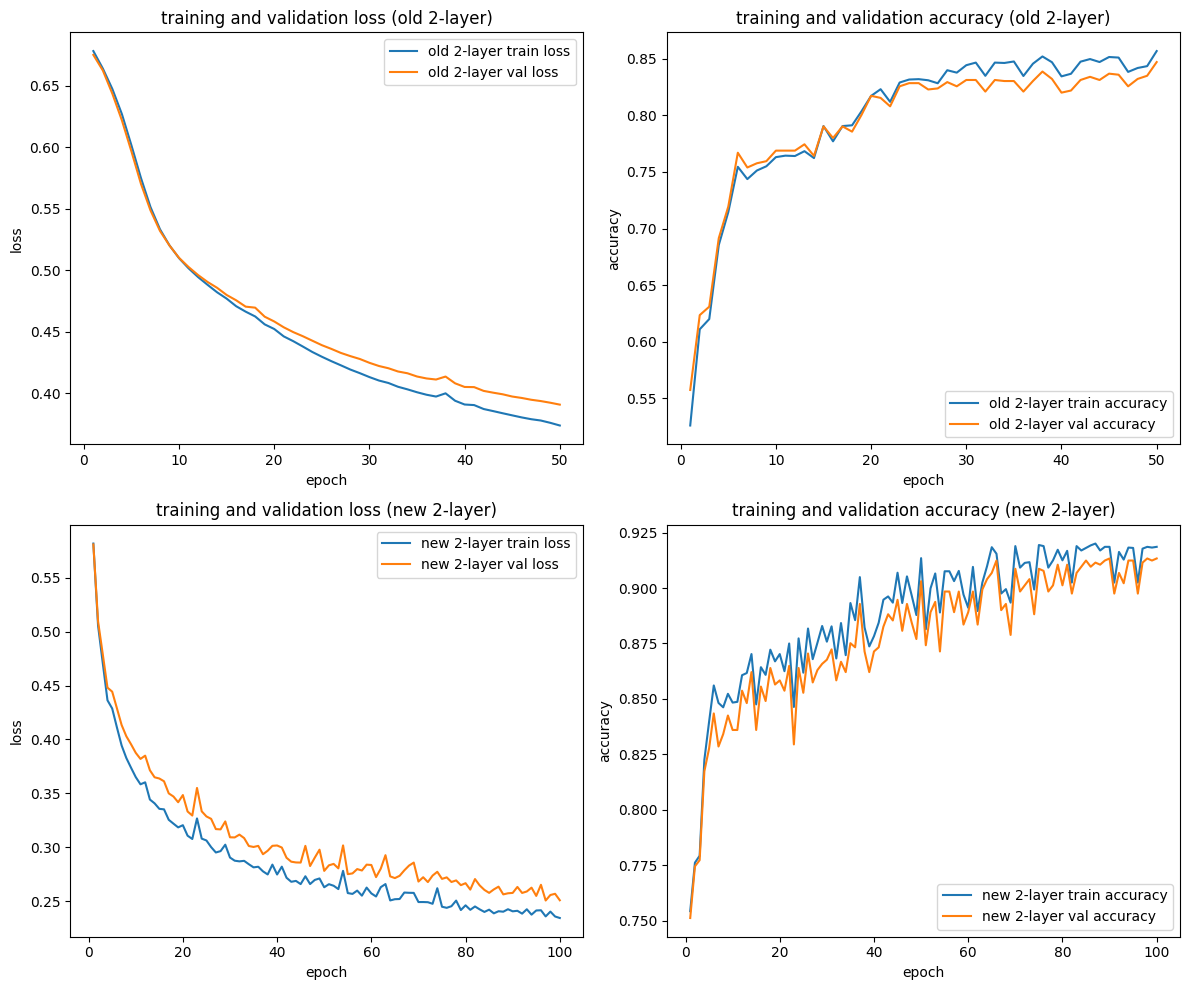

old 2-layer test acc: tensor(0.8416)
new 2-layer test acc: tensor(0.9074)


In [21]:
### part k: Hyperparameter Tuning. Write your updated hyperparameter values and show improvement for the TwoLayerNetwork
lr_tuned         = 0.005      # larger LR for faster learning
num_epochs_tuned = 100        # more epochs so model can converge better
hidden_size_tuned = 12        # bigger hidden layer (more capacity)
activation_tuned  = 'sigmoid' # keep same activation

print("tuned hyperparameters:")
print("lr:", lr_tuned)
print("num_epochs:", num_epochs_tuned)
print("hidden_size: ", hidden_size_tuned)
print("activation:", activation_tuned)

# re-init and train model (2-layer NN)
twoLayerNN_tuned, criterion_tuned, optimizer_tuned = init_twoLayerNN(X_train.shape[1], hidden_size_tuned, activation_tuned, lr=lr_tuned)
results_two_tuned = train(twoLayerNN_tuned, criterion_tuned, optimizer_tuned, train_loader, val_loader, num_epochs=num_epochs_tuned)
two_train_loss_tuned, two_valid_loss_tuned, two_train_acc_tuned, two_valid_acc_tuned = results_two_tuned

# for plots
epochs_old = range(1, num_epochs + 1)
epochs_tuned = range(1, num_epochs_tuned + 1)

print("old vs new model training and validation loss curves, accuracy curves:")

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs_old, two_train_loss, label='old 2-layer train loss')
plt.plot(epochs_old, two_valid_loss, label='old 2-layer val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training and validation loss (old 2-layer)')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epochs_old, two_train_acc, label='old 2-layer train accuracy')
plt.plot(epochs_old, two_valid_acc, label='old 2-layer val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('training and validation accuracy (old 2-layer)')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epochs_tuned, two_train_loss_tuned, label='new 2-layer train loss')
plt.plot(epochs_tuned, two_valid_loss_tuned, label='new 2-layer val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training and validation loss (new 2-layer)')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epochs_tuned, two_train_acc_tuned, label='new 2-layer train accuracy')
plt.plot(epochs_tuned, two_valid_acc_tuned, label='new 2-layer val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('training and validation accuracy (new 2-layer)')
plt.legend()

plt.tight_layout()
plt.show()

# eval accuracy of new model
two_test_acc_tuned = evaluate_acc(twoLayerNN_tuned, test_loader)

print("old 2-layer test acc:", two_test_acc)
print("new 2-layer test acc:", two_test_acc_tuned)